<a href="https://colab.research.google.com/github/Lehuutien2908/DataMining/blob/main/research/training_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dự đoán nguy cơ mắc bệnh tim

Notebook này trình bày toàn bộ quy trình xử lý dữ liệu, xây dựng và so sánh các mô hình (MLP, Random Forest, XGBoost, SVM) nhằm dự đoán khả năng mắc bệnh tim dựa trên các chỉ số lâm sàng.


## Quy trình tổng quát
- Khảo sát dữ liệu, kiểm tra thiếu và ngoại lệ
- Làm sạch, chuẩn hóa và chọn đặc trưng
- Chia dữ liệu train/test (stratify theo nhãn)
- Huấn luyện MLP (Keras Sequential) và các mô hình so sánh: Random Forest, XGBoost, SVM
- Đánh giá Accuracy, Precision, Recall, F1, Specificity, AUC-ROC


## Association Rules với Apriori Algorithm

Phân tích luật kết hợp để tìm các mẫu và mối quan hệ giữa các đặc trưng trong dữ liệu bệnh tim.


In [5]:
# Trong cell đầu tiên, chạy:
!pip install torch torchvision
!pip -q install pytorch-tabnet optuna

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, roc_curve
)


import torch
import optuna
from pytorch_tabnet.tab_model import TabNetClassifier

import joblib

MODELS_DIR = Path("../backend/app/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

DATA_PATH = Path("heart.csv")


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.0000

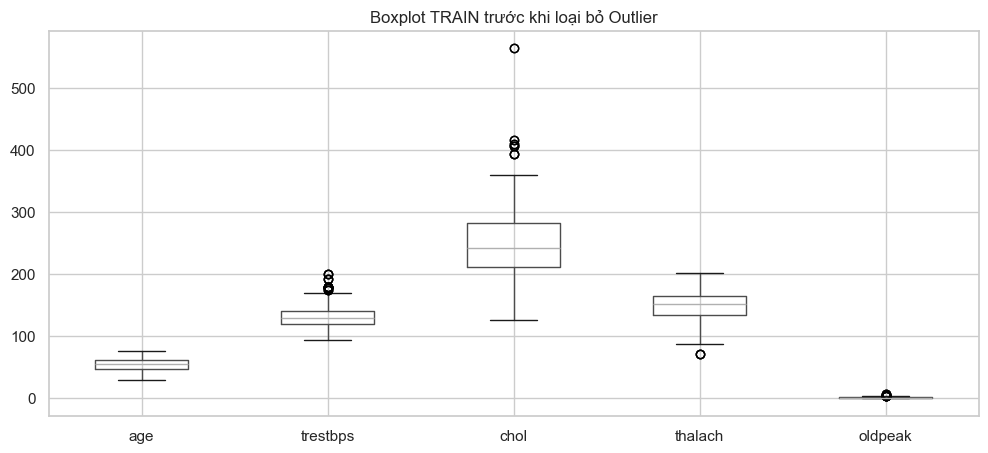

   - 'trestbps': remove TRAIN=20, TEST=10 (bounds: 90.000, 170.000)
   - 'chol': remove TRAIN=12, TEST=4 (bounds: 108.500, 384.500)
   - 'thalach': remove TRAIN=3, TEST=1 (bounds: 81.000, 217.000)
   - 'oldpeak': remove TRAIN=12, TEST=2 (bounds: -2.400, 4.000)
-> TRAIN removed: 47 rows | TRAIN shape: (670, 14)
-> TEST  removed: 17 rows | TEST  shape: (291, 14)


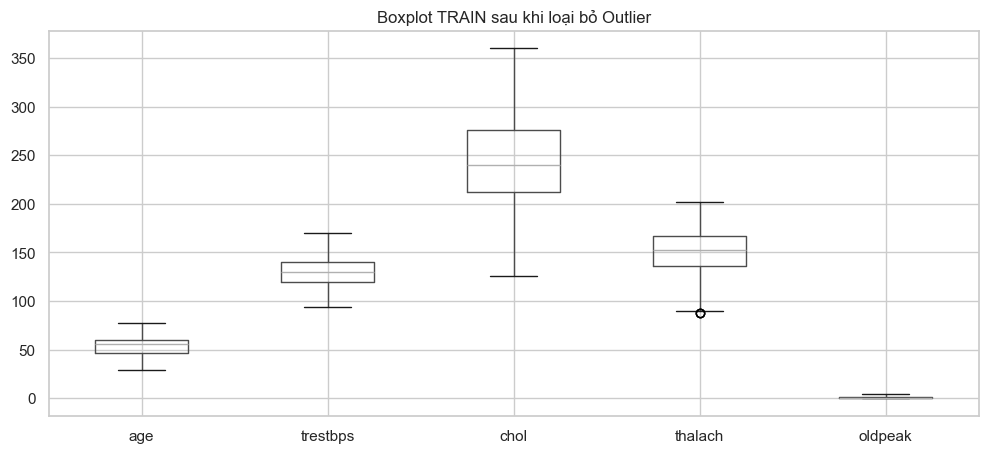

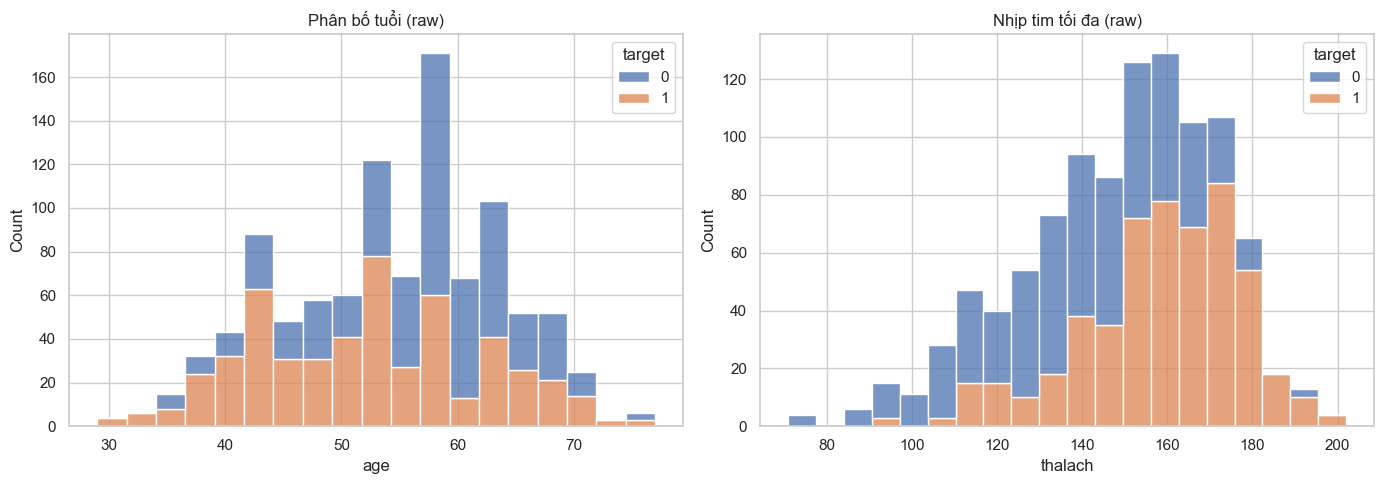

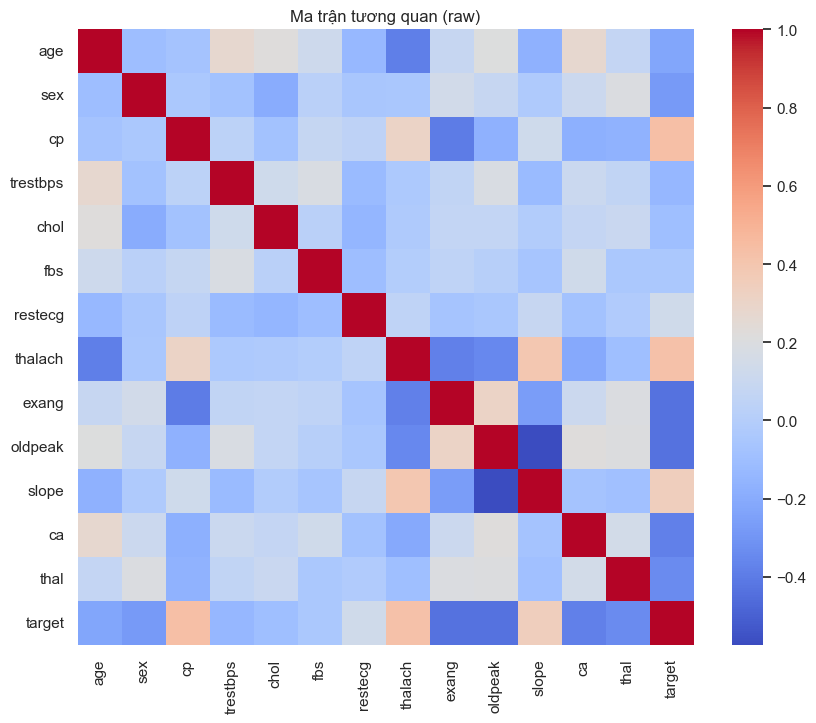

After outlier removal - X_train/X_test: (670, 13) (291, 13)


In [ ]:
raw_df = pd.read_csv(DATA_PATH)

print(raw_df.head())
print(raw_df.describe())
print(raw_df.isna().sum())

if "target" not in raw_df.columns:
    raise ValueError("Không thấy cột 'target' trong heart.csv")

# ============================
# Train/Test split
# ============================
X = raw_df.drop(columns="target")
y = raw_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

train_df = X_train.copy()
train_df["target"] = y_train.values

test_df = X_test.copy()
test_df["target"] = y_test.values

print("Before outlier removal - Train/Test:", train_df.shape, test_df.shape)

# ============================
# Outlier removal
# ============================
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Boxplot trên TRAIN trước khi lọc (đúng hơn so với toàn bộ dataset)
plt.figure(figsize=(12, 5))
train_df[continuous_cols].boxplot()
plt.title("Boxplot TRAIN trước khi loại bỏ Outlier")
plt.show()

old_train_rows = train_df.shape[0]
old_test_rows = test_df.shape[0]

iqr_bounds = {}  # lưu ngưỡng để báo cáo

for col in continuous_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    iqr_bounds[col] = (float(lower_bound), float(upper_bound))

    # đếm outlier theo ngưỡng TRAIN
    train_out = ((train_df[col] < lower_bound) | (train_df[col] > upper_bound)).sum()
    test_out  = ((test_df[col]  < lower_bound) | (test_df[col]  > upper_bound)).sum()

    if train_out > 0 or test_out > 0:
        print(f"   - '{col}': remove TRAIN={train_out}, TEST={test_out} (bounds: {lower_bound:.3f}, {upper_bound:.3f})")

    # lọc cả train và test theo cùng bounds
    train_df = train_df[(train_df[col] >= lower_bound) & (train_df[col] <= upper_bound)]
    test_df  = test_df[(test_df[col]  >= lower_bound) & (test_df[col]  <= upper_bound)]

print(f"-> TRAIN removed: {old_train_rows - train_df.shape[0]} rows | TRAIN shape: {train_df.shape}")
print(f"-> TEST  removed: {old_test_rows  - test_df.shape[0]} rows | TEST  shape: {test_df.shape}")

# Boxplot sau lọc (TRAIN)
plt.figure(figsize=(12, 5))
train_df[continuous_cols].boxplot()
plt.title("Boxplot TRAIN sau khi loại bỏ Outlier")
plt.show()

# ============================
# (Optional) EDA
# ============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=raw_df, x="age", hue="target", multiple="stack", ax=axes[0])
sns.histplot(data=raw_df, x="thalach", hue="target", multiple="stack", ax=axes[1])
axes[0].set_title("Phân bố tuổi (raw)")
axes[1].set_title("Nhịp tim tối đa (raw)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(raw_df.corr(numeric_only=True), cmap="coolwarm", square=True)
plt.title("Ma trận tương quan (raw)")
plt.show()

# ============================
# Sau bước này: lấy lại X_train/X_test/y_train/y_test từ train_df/test_df đã clean
# ============================
X_train = train_df.drop(columns="target")
y_train = train_df["target"]

X_test  = test_df.drop(columns="target")
y_test  = test_df["target"]

print("After outlier removal - X_train/X_test:", X_train.shape, X_test.shape)



In [7]:
import time
from sklearn.base import clone

def cv_auc_and_time(model, X_df, y_sr, features, cv_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=seed)
    aucs, fit_times = [], []

    for tr_idx, va_idx in skf.split(X_df, y_sr):
        X_tr = X_df.iloc[tr_idx][features]
        X_va = X_df.iloc[va_idx][features]
        y_tr = y_sr.iloc[tr_idx]
        y_va = y_sr.iloc[va_idx]

        m = clone(model)
        t0 = time.perf_counter()
        m.fit(X_tr, y_tr)
        fit_times.append(time.perf_counter() - t0)

        proba = m.predict_proba(X_va)[:, 1]
        aucs.append(roc_auc_score(y_va, proba))

    return float(np.mean(aucs)), float(np.std(aucs)), float(np.mean(fit_times))


def sweep_topk(model, X_df, y_sr, ranked_features, k_min=1, k_max=None, cv_splits=5, seed=42):
    if k_max is None:
        k_max = len(ranked_features)

    rows = []
    for k in range(k_min, k_max + 1):
        feats = ranked_features[:k]
        mean_auc, std_auc, mean_fit_time = cv_auc_and_time(
            model, X_df, y_sr, feats, cv_splits=cv_splits, seed=seed
        )
        rows.append({
            "k": k,
            "mean_auc": mean_auc,
            "std_auc": std_auc,
            "mean_fit_time_sec": mean_fit_time,
            "features": feats
        })

    res = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

    best_row = res.loc[res["mean_auc"].idxmax()]
    threshold = best_row["mean_auc"] - best_row["std_auc"]
    chosen = res[res["mean_auc"] >= threshold].iloc[0]

    return res, best_row, chosen


# ---- RF ranking (train only) ----
rf_rank = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)
rf_rank.fit(X_train, y_train)

gini_importances = pd.Series(rf_rank.feature_importances_, index=X_train.columns).sort_values(ascending=False)
ranked_features = gini_importances.index.tolist()

print("\n=== GINI IMPORTANCE (RF trained on TRAIN) ===")
print(gini_importances)

# ---- Sweep top-k (train only) ----
rf_for_sweep = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

rf_table, rf_best, rf_chosen = sweep_topk(
    rf_for_sweep, X_train, y_train, ranked_features,
    k_min=1, k_max=len(ranked_features),
    cv_splits=5, seed=RANDOM_STATE
)

selected_features = rf_chosen["features"]

print("\n=== RF sweep top-k (CV on TRAIN) ===")
print(rf_table[["k", "mean_auc", "std_auc", "mean_fit_time_sec"]])
print("\nBest RF row:", dict(rf_best[["k","mean_auc","std_auc","mean_fit_time_sec"]]))
print("Chosen (smallest within 1σ best):", dict(rf_chosen[["k","mean_auc","std_auc","mean_fit_time_sec"]]))
print("\nSELECTED FEATURES:", selected_features)



=== GINI IMPORTANCE (RF trained on TRAIN) ===
cp          0.144550
ca          0.122160
thalach     0.114005
age         0.104865
thal        0.104490
oldpeak     0.102206
chol        0.081418
trestbps    0.068547
exang       0.057777
slope       0.035433
sex         0.035119
restecg     0.018663
fbs         0.010769
dtype: float64

=== RF sweep top-k (CV on TRAIN) ===
     k  mean_auc   std_auc  mean_fit_time_sec
0    1  0.779543  0.024126           2.147209
1    2  0.855858  0.035861           2.187407
2    3  0.961344  0.009974           2.005148
3    4  0.979896  0.011653           2.144504
4    5  0.986928  0.007603           2.071431
5    6  0.994047  0.004849           1.975329
6    7  0.994806  0.005019           2.108350
7    8  0.994918  0.005349           2.018819
8    9  0.995434  0.003990           2.127726
9   10  0.995120  0.005069           2.006767
10  11  0.996037  0.004644           1.954623
11  12  0.996216  0.004865           1.957888
12  13  0.996172  0.004878   

In [8]:
scaler = StandardScaler()
X_train_selected = scaler.fit_transform(X_train[selected_features])
X_test_selected  = scaler.transform(X_test[selected_features])

def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    balanced_accuracy = (sensitivity + specificity) / 2

    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "sensitivity": sensitivity,
        "npv": npv,
        "fpr": fpr,
        "fnr": fnr,
        "balanced_accuracy": balanced_accuracy,
        "auc": roc_auc_score(y_true, y_prob),
    }

results = []
roc_curves = {}


In [9]:
svm_params = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
}

svm_grid = GridSearchCV(
    SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    svm_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

svm_grid.fit(X_train_selected, y_train)
svm_model = svm_grid.best_estimator_
print("SVM best params:", svm_grid.best_params_)

svm_probs = svm_model.predict_proba(X_test_selected)[:, 1]
results.append(evaluate_model("SVM (RBF)", y_test.values, svm_probs))
roc_curves["SVM (RBF)"] = roc_curve(y_test, svm_probs)


SVM best params: {'C': 100, 'gamma': 1}


In [10]:
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=xgb_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_grid.fit(X_train_selected, y_train)
xgb_model = xgb_grid.best_estimator_
print("XGBoost best params:", xgb_grid.best_params_)

xgb_probs = xgb_model.predict_proba(X_test_selected)[:, 1]
results.append(evaluate_model("XGBoost", y_test.values, xgb_probs))
roc_curves["XGBoost"] = roc_curve(y_test, xgb_probs)


XGBoost best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [11]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train_selected, y_train)
rf_probs = rf_model.predict_proba(X_test_selected)[:, 1]

results.append(evaluate_model("Random Forest", y_test.values, rf_probs))
roc_curves["Random Forest"] = roc_curve(y_test, rf_probs)


In [15]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

# TabNet needs float32 numpy arrays
Xtr_all = X_train_selected.astype(np.float32)
ytr_all = y_train.values.astype(int)

Xte = X_test_selected.astype(np.float32)
yte = y_test.values.astype(int)

def objective(trial: optuna.Trial) -> float:
    n_da = trial.suggest_categorical("n_da", [8, 16, 24])
    n_steps = trial.suggest_int("n_steps", 3, 5)
    gamma = trial.suggest_float("gamma", 1.1, 1.7)
    lambda_sparse = trial.suggest_float("lambda_sparse", 1e-6, 2e-4, log=True)
    mask_type = trial.suggest_categorical("mask_type", ["entmax", "sparsemax"])
    lr = trial.suggest_float("lr", 5e-3, 2e-2, log=True)

    batch_size = trial.suggest_categorical("batch_size", [64, 128])
    virtual_batch_size = trial.suggest_categorical("virtual_batch_size", [32, 64])
    if virtual_batch_size > batch_size:
        virtual_batch_size = batch_size

    n_independent = trial.suggest_int("n_independent", 1, 2)
    n_shared = trial.suggest_int("n_shared", 1, 2)

    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
    aucs = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(Xtr_all, ytr_all), start=1):
        Xtr, ytr = Xtr_all[tr_idx], ytr_all[tr_idx]
        Xva, yva = Xtr_all[va_idx], ytr_all[va_idx]

        tabnet = TabNetClassifier(
            n_d=n_da,
            n_a=n_da,
            n_steps=n_steps,
            gamma=gamma,
            n_independent=n_independent,
            n_shared=n_shared,
            lambda_sparse=lambda_sparse,
            mask_type=mask_type,
            optimizer_fn=torch.optim.Adam,
            optimizer_params=dict(lr=lr),
            scheduler_fn=torch.optim.lr_scheduler.StepLR,
            scheduler_params=dict(step_size=20, gamma=0.9),
            seed=RANDOM_STATE,
            verbose=0
        )

        tabnet.fit(
            Xtr, ytr,
            eval_set=[(Xva, yva)],
            eval_metric=["auc"],
            max_epochs=60,
            patience=10,
            batch_size=batch_size,
            virtual_batch_size=virtual_batch_size,
            num_workers=0,
            drop_last=False
        )

        p = tabnet.predict_proba(Xva)[:, 1]
        aucs.append(roc_auc_score(yva, p))

        trial.report(float(np.mean(aucs)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(aucs))


sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.HyperbandPruner()
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)

study.optimize(objective, n_trials=10, show_progress_bar=True)

print("\n===== OPTUNA BEST (2-fold, 10 trials) =====")
print("Best CV AUC:", study.best_value)
print("Best params:", study.best_params)

best = study.best_params
batch_size = best["batch_size"]
virtual_batch_size = best["virtual_batch_size"]
if virtual_batch_size > batch_size:
    virtual_batch_size = batch_size

tabnet_best = TabNetClassifier(
    n_d=best["n_da"],
    n_a=best["n_da"],
    n_steps=best["n_steps"],
    gamma=best["gamma"],
    n_independent=best["n_independent"],
    n_shared=best["n_shared"],
    lambda_sparse=best["lambda_sparse"],
    mask_type=best["mask_type"],
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=best["lr"]),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=20, gamma=0.9),
    seed=RANDOM_STATE,
    verbose=10
)

tabnet_best.fit(
    Xtr_all, ytr_all,
    eval_set=[(Xte, yte)],
    eval_name=["test"],
    eval_metric=["auc"],
    max_epochs=120,
    patience=20,
    batch_size=batch_size,
    virtual_batch_size=virtual_batch_size,
    num_workers=0,
    drop_last=False
)

tabnet_probs = tabnet_best.predict_proba(Xte)[:, 1]
results.append(evaluate_model("TabNet", yte, tabnet_probs))
roc_curves["TabNet (Optuna)"] = study.best_value

tabnet_best.save_model(str(MODELS_DIR / "tabnet_optuna_2fold_10trial"))
print("Saved:", (MODELS_DIR / "tabnet_optuna_2fold_10trial.zip").resolve())


[I 2026-01-14 21:49:41,021] A new study created in memory with name: no-name-fcd2a992-cff3-440b-b4d7-66359abb5969


CUDA available: False
Running on CPU


  0%|          | 0/10 [00:00<?, ?it/s]


Early stopping occurred at epoch 37 with best_epoch = 27 and best_val_0_auc = 0.92637

Early stopping occurred at epoch 18 with best_epoch = 8 and best_val_0_auc = 0.94818


Best trial: 0. Best value: 0.937276:  10%|█         | 1/10 [00:38<05:42, 38.06s/it]

...

[I 2026-01-14 21:54:36,921] Trial 7 finished with value: 0.931420999856754 and parameters: {'n_da': 24, 'n_steps': 3, 'gamma': 1.146187945897276, 'lambda_sparse': 4.642231396020666e-06, 'mask_type': 'sparsemax', 'lr': 0.015328757474855513, 'batch_size': 128, 'virtual_batch_size': 32, 'n_independent': 2, 'n_shared': 2}. Best is trial 6 with value: 0.955396791290646.

Early stopping occurred at epoch 32 with best_epoch = 22 and best_val_0_auc = 0.91839


Best trial: 6. Best value: 0.955397:  90%|█████████ | 9/10 [05:10<00:30, 30.72s/it]

[I 2026-01-14 21:54:51,649] Trial 8 pruned. 

Early stopping occurred at epoch 25 with best_epoch = 15 and best_val_0_auc = 0.92666


Best trial: 6. Best value: 0.955397: 100%|██████████| 10/10 [05:23<00:00, 32.35s/it]


[I 2026-01-14 21:55:04,560] Trial 9 pruned. 

===== OPTUNA BEST (2-fold, 10 trials) =====
Best CV AUC: 0.955396791290646
Best params: {'n_da': 24, 'n_steps': 4, 'gamma': 1.5625803079727365, 'lambda_sparse': 1.3684800764953181e-05, 'mask_type': 'entmax', 'lr': 0.005179333108777708, 'batch_size': 64, 'virtual_batch_size': 32, 'n_independent': 2, 'n_shared': 2}
epoch 0  | loss: 1.14507 | test_auc: 0.76598 |  0:00:01s
epoch 10 | loss: 0.30323 | test_auc: 0.93286 |  0:00:12s
epoch 20 | loss: 0.23022 | test_auc: 0.94643 |  0:00:21s
epoch 30 | loss: 0.23276 | test_auc: 0.95106 |  0:00:31s
epoch 40 | loss: 0.1743  | test_auc: 0.9704  |  0:00:41s
epoch 50 | loss: 0.20396 | test_auc: 0.9705  |  0:00:51s
epoch 60 | loss: 0.16683 | test_auc: 0.9653  |  0:01:02s
epoch 70 | loss: 0.15455 | test_auc: 0.96563 |  0:01:11s
epoch 80 | loss: 0.13536 | test_auc: 0.98719 |  0:01:20s
epoch 90 | loss: 0.13461 | test_auc: 0.96288 |  0:01:28s
epoch 100| loss: 0.16946 | test_auc: 0.96695 |  0:01:38s

Early stopp


=== RESULTS (sorted by AUC) ===
                           model  accuracy  precision    recall        f1  \
0                      SVM (RBF)  0.969072   1.000000  0.940000  0.969072   
2                  Random Forest  0.969072   0.979592  0.960000  0.969697   
1                        XGBoost  0.955326   0.959732  0.953333  0.956522   
3  TabNet (Optuna 2fold-10trial)  0.917526   0.956522  0.880000  0.916667   

   specificity  sensitivity       npv       fpr       fnr  balanced_accuracy  \
0     1.000000     0.940000  0.940000  0.000000  0.060000           0.970000   
2     0.978723     0.960000  0.958333  0.021277  0.040000           0.969362   
1     0.957447     0.953333  0.950704  0.042553  0.046667           0.955390   
3     0.957447     0.880000  0.882353  0.042553  0.120000           0.918723   

        auc  
0  0.998723  
2  0.997589  
1  0.991631  
3  0.987187  


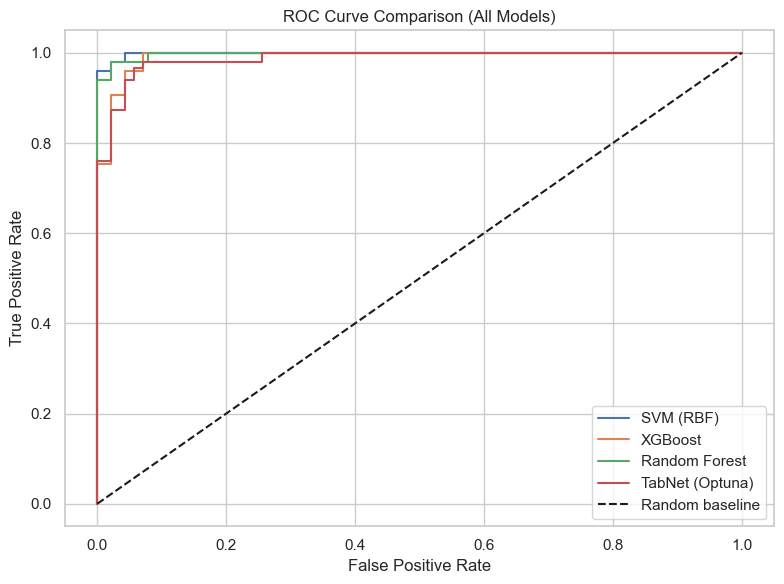


Đã lưu:
 - scaler.pkl
 - selected_features.pkl
 - svm_model.pkl
 - rf_model.pkl
 - tabnet_optuna.zip
 - feature_selection_meta.json
Models dir: E:\DataMinig\backend\app\models


In [13]:
results_df = pd.DataFrame(results).sort_values(by="auc", ascending=False)
print("\n=== RESULTS (sorted by AUC) ===")
print(results_df)

plt.figure(figsize=(8, 6))
for name, (fpr, tpr, _) in roc_curves.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (All Models)")
plt.legend()
plt.tight_layout()
plt.show()


joblib.dump(scaler, MODELS_DIR / "scaler.pkl")
joblib.dump(selected_features, MODELS_DIR / "selected_features.pkl")

# XGBoost
xgb_model.save_model(str(MODELS_DIR / "xgb_model.json"))


# SVM / RF
joblib.dump(svm_model, MODELS_DIR / "svm_model.pkl")
joblib.dump(rf_model, MODELS_DIR / "rf_model.pkl")

# Save meta
meta = {
    "selected_features": selected_features,
    "gini_importances": gini_importances.to_dict(),
    "rf_cv_best": {
        "k": int(rf_best["k"]),
        "mean_auc": float(rf_best["mean_auc"]),
        "std_auc": float(rf_best["std_auc"]),
        "mean_fit_time_sec": float(rf_best["mean_fit_time_sec"]),
    },
    "rf_cv_chosen": {
        "k": int(rf_chosen["k"]),
        "mean_auc": float(rf_chosen["mean_auc"]),
        "std_auc": float(rf_chosen["std_auc"]),
        "mean_fit_time_sec": float(rf_chosen["mean_fit_time_sec"]),
    },
    "tabnet_optuna_best": {
        "best_cv_auc": float(study.best_value),
        "best_params": study.best_params
    }
}
pd.Series(meta, dtype="object").to_json(MODELS_DIR / "feature_selection_meta.json", force_ascii=False, indent=2)

print("\nĐã lưu:")
print(" - scaler.pkl")
print(" - selected_features.pkl")
print(" - svm_model.pkl")
print(" - rf_model.pkl")
print(" - tabnet_optuna.zip")
print(" - feature_selection_meta.json")
print("Models dir:", MODELS_DIR.resolve())

